# Lock-Free Stack Benchmark Visualization
Converts benchmark_results.csv to visualization plots

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Read benchmark results
csv_file = 'benchmark_results.csv'

if not os.path.exists(csv_file):
    print(f"Error: {csv_file} not found. Run benchmark first!")
else:
    df = pd.read_csv(csv_file)
    print("Benchmark Results:")
    print(df.to_string(index=False))
    print()

Benchmark Results:
                   Workload  Avg_Time_ms  Max_Time_ms  Min_Time_ms  Total_Ops
  Balanced (50/50 push/pop)       0.0025       2.0987       0.0006      80000
Push-Heavy (80/20 push/pop)       0.0013       0.5534       0.0005     200000
 Pop-Heavy (20/80 push/pop)       0.0018       0.4276       0.0005     200000



## Main Benchmark Dashboard (2x2)

Graph saved as benchmark_results.png


Graph saved as benchmark_results.png


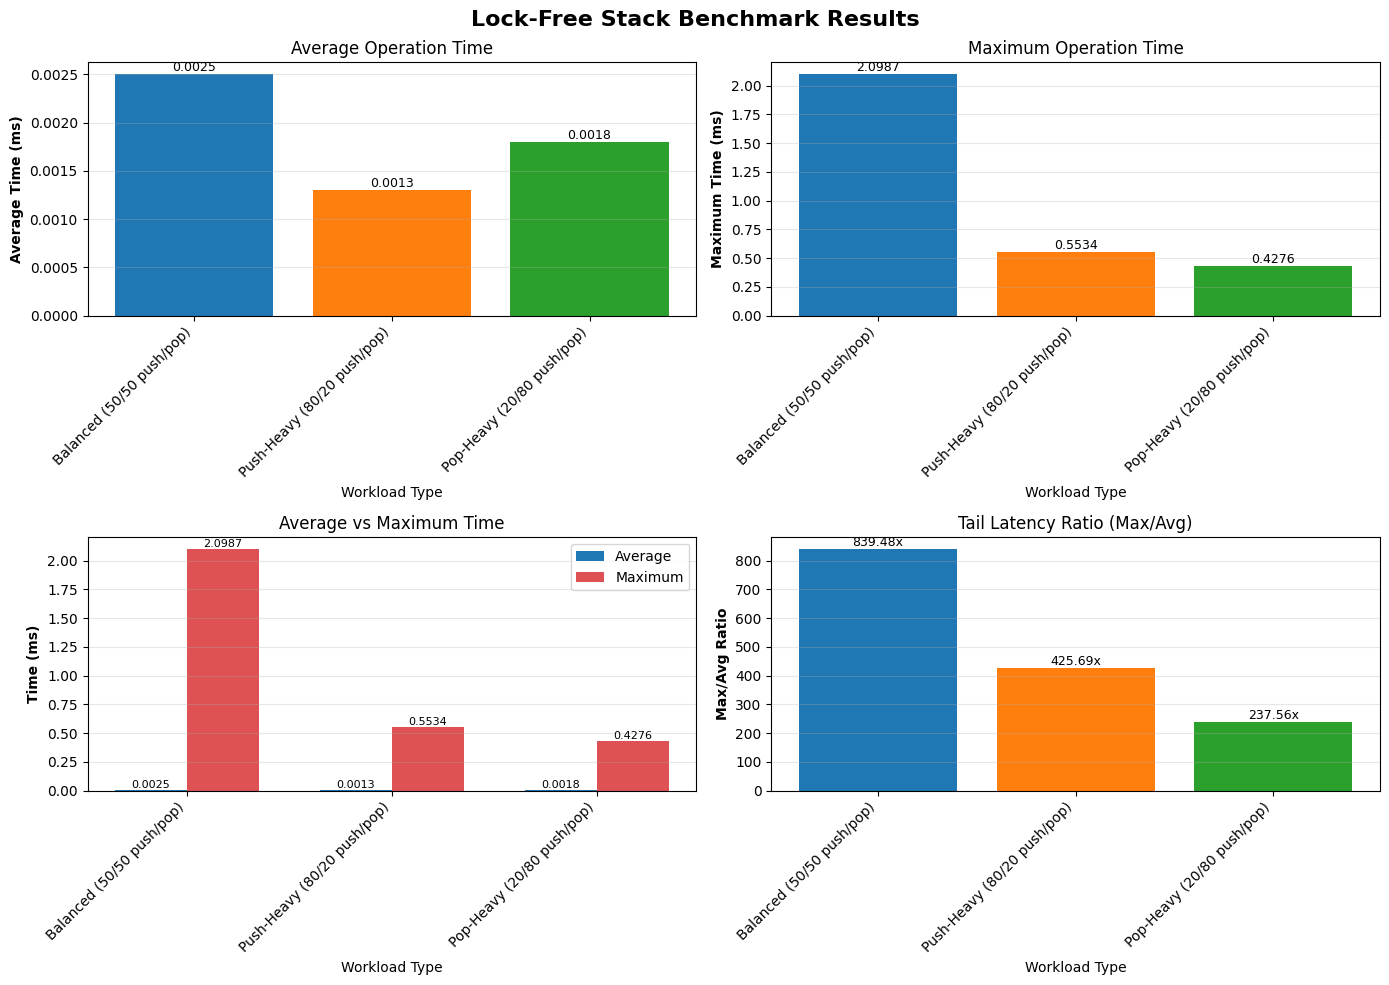

In [7]:
# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Lock-Free Stack Benchmark Results', fontsize=16, fontweight='bold')

# 1. Average operation time
ax1 = axes[0, 0]
bars1 = ax1.bar(range(len(df)), df['Avg_Time_ms'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1.set_ylabel('Average Time (ms)', fontweight='bold')
ax1.set_xlabel('Workload Type')
ax1.set_title('Average Operation Time')
ax1.set_xticks(range(len(df)))
ax1.set_xticklabels(df['Workload'], rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=9)

# 2. Maximum operation time
ax2 = axes[0, 1]
bars2 = ax2.bar(range(len(df)), df['Max_Time_ms'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_ylabel('Maximum Time (ms)', fontweight='bold')
ax2.set_xlabel('Workload Type')
ax2.set_title('Maximum Operation Time')
ax2.set_xticks(range(len(df)))
ax2.set_xticklabels(df['Workload'], rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=9)

# 3. Average vs Maximum comparison
ax3 = axes[1, 0]
x = np.arange(len(df))
width = 0.35
bars3a = ax3.bar(x - width/2, df['Avg_Time_ms'], width, label='Average', color='#1f77b4', alpha=1)
bars3b = ax3.bar(x + width/2, df['Max_Time_ms'], width, label='Maximum', color='#d62728', alpha=0.8)
ax3.set_ylabel('Time (ms)', fontweight='bold')
ax3.set_xlabel('Workload Type')
ax3.set_title('Average vs Maximum Time')
ax3.set_xticks(x)
ax3.set_xticklabels(df['Workload'], rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars3a, bars3b]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=8)

# 4. Tail latency ratio (Max/Avg)
ax4 = axes[1, 1]
ratio = df['Max_Time_ms'] / df['Avg_Time_ms']
bars4 = ax4.bar(range(len(df)), ratio, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax4.set_ylabel('Max/Avg Ratio', fontweight='bold')
ax4.set_xlabel('Workload Type')
ax4.set_title('Tail Latency Ratio (Max/Avg)')
ax4.set_xticks(range(len(df)))
ax4.set_xticklabels(df['Workload'], rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}x',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
print("Graph saved as benchmark_results.png")
plt.show()